## Book Accuracy Training Plots

In [1]:
BLUE="#2ca3dd"
YELLOW="#ffd35a"
RED='#ec2027'
CHILL_BROWN="#948979"

In [2]:
import json, math, re
from pathlib import Path

import numpy as np
import torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from torchvision.models.resnet import ResNet, BasicBlock

RUNS = Path("/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/aug_17_run")                       # <-- output dir of train_depth_sweep.py
DATA = Path("/home/stephen/imagenet")     # <-- edit
device = "cuda" if torch.cuda.is_available() else "cpu"

MODEL_DEPTHS = {"plain8": 8, "plain14": 14, "plain20": 20, "plain26": 26,
                "plain34": 34, "plain56": 56, "plain74": 74, "resnet74": 74}
MODELS = [m for m in MODEL_DEPTHS if (RUNS / m).exists()]

def color_of(name):
    """Plain nets: dark->light with depth. ResNet: red."""
    if name == "resnet74":
        return "crimson"
    depths = sorted(d for m, d in MODEL_DEPTHS.items() if m != "resnet74")
    return plt.cm.viridis((depths.index(MODEL_DEPTHS[name])+1.0) / (len(depths) +1.0))

print(torch.__version__, device, "| runs found:", MODELS)

2.12.1+cu130 cuda | runs found: ['plain8', 'plain14', 'plain20', 'plain26', 'plain34', 'plain56', 'plain74', 'resnet74']


In [3]:
# --- model definitions (mirrors train_depth_sweep.py) ---
class PlainBasicBlock(BasicBlock):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.downsample = None

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        return out

LAYER_CFG = {8: [1,1,1,1], 14: [2,1,1,2], 20: [2,2,3,2], 26: [3,3,3,3],
             34: [4,4,4,4], 56: [3,4,17,3], 74: [3,4,26,3]}

def make_net(depth_target, use_skip, num_classes=1000):
    block = BasicBlock if use_skip else PlainBasicBlock
    model = ResNet(block, LAYER_CFG[depth_target], num_classes=num_classes)
    if depth_target == 8:
        model.layer4 = nn.Identity()
        model.fc = nn.Linear(256, num_classes)
    return model

def blocks_of(model):
    return [b for s in (model.layer1, model.layer2, model.layer3, model.layer4)
            if isinstance(s, nn.Sequential) for b in s]

In [4]:
# --- metrics loading: prefer metrics.npz, fall back to metrics.jsonl ---
def load_metrics(name):
    d = RUNS / name
    if (d / "metrics.npz").exists():
        return dict(np.load(d / "metrics.npz"))
    recs = [json.loads(l) for l in open(d / "metrics.jsonl") if l.strip()]
    out = {}
    for k in recs[0]:
        if k in ("block_grad_norms", "block_acts"):
            continue
        out[k] = np.array([r.get(k, np.nan) for r in recs], dtype=np.float64)
    out["block_grad_norms"] = np.array([r["block_grad_norms"] for r in recs])
    return out

M = {name: load_metrics(name) for name in MODELS}
for name in MODELS:
    print(f"{name:9s} records={len(M[name]['step']):5d} "
          f"last step={int(M[name]['step'][-1])}")

plain8    records=  400 last step=40000
plain14   records=  500 last step=50000
plain20   records=  600 last step=60000
plain26   records=  700 last step=70000
plain34   records=  800 last step=80000
plain56   records=  900 last step=90000
plain74   records= 1000 last step=100000
resnet74  records= 1100 last step=110000


In [5]:
def list_ckpts(name):
    return sorted(int(re.search(r"(\d+)", p.stem).group(1))
                  for p in (RUNS / name).glob("ckpt_step*.pt"))

def load_model(name, step=None):
    d = RUNS / name
    path = d / "final.pt" if step is None else d / f"ckpt_step{step:06d}.pt"
    model = make_net(MODEL_DEPTHS[name], use_skip=name.startswith("resnet"))
    model.load_state_dict(torch.load(path, map_location=device))
    return model.to(device).eval()

print("plain74 checkpoints:", list_ckpts("plain74")[:5], "...",
      list_ckpts("plain74")[-2:])

plain74 checkpoints: [1000, 2000, 3000, 4000, 5000] ... [99000, 100000]


In [6]:
model=load_model('plain8')

In [7]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): PlainBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (layer2): Sequential(
    (0): PlainBasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, a

## P23

In [8]:
def style_ax(ax, color=CHILL_BROWN, tick_fontsize=15):
    ax.spines[:].set_color(color)
    ax.tick_params(colors=color, which='both', labelsize=tick_fontsize)
    ax.xaxis.label.set_color(color)
    ax.yaxis.label.set_color(color)
    ax.title.set_color(color)

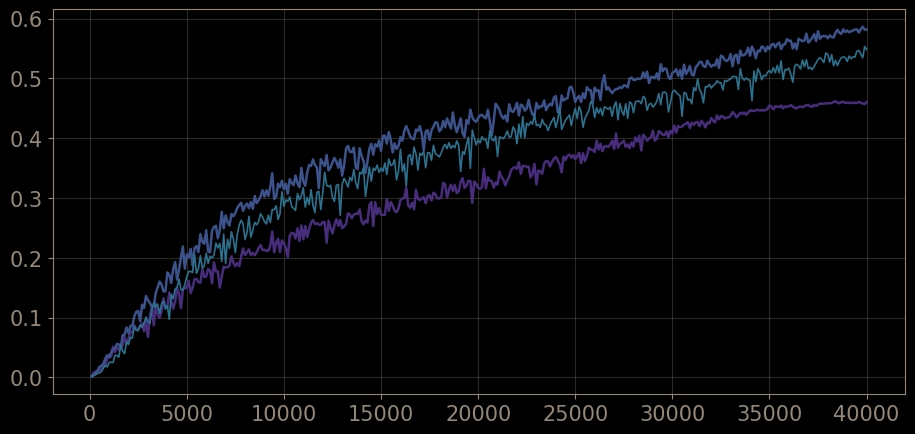

In [9]:
fig= plt.figure(figsize=(11, 5), facecolor='k')
ax=fig.add_subplot(111, facecolor='k')
m='plain8'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.8, alpha=1.0)

m='plain14'
plt.plot(M[m]["step"][:400], M[m]["val_top1"][:400], color=color_of(m), label=m, lw=1.8, alpha=1.0)

m='plain20'
plt.plot(M[m]["step"][:400], M[m]["val_top1"][:400], color=color_of(m), label=m, lw=1.2, alpha=1.0)
style_ax(ax)

ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
# plt.ylim([0, 0.8])
plt.savefig('/home/stephen/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/3_resnets/graphics/accuracy_curves_first_3.svg')

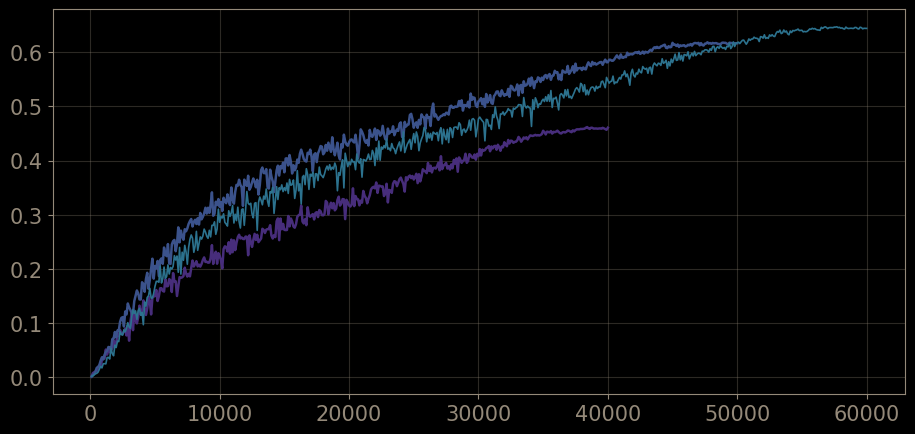

In [10]:
fig= plt.figure(figsize=(11, 5), facecolor='k')
ax=fig.add_subplot(111, facecolor='k')
m='plain8'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.8, alpha=1.0)

m='plain14'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.8, alpha=1.0)

m='plain20'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=1.0)
style_ax(ax)

ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
# plt.ylim([0, 0.8])
plt.savefig('/home/stephen/Stephencwelch Dropbox/welch_labs/ai_book_vol_2/3_resnets/graphics/accuracy_curves_first_3b.svg')

In [16]:
m='plain14'
M[m]["val_top1"][400]

np.float64(0.586)

In [17]:
m='plain20'
M[m]["val_top1"][400]

np.float64(0.5428)

In [15]:
m='plain8'
M[m]["val_top1"][-1]

np.float64(0.4606)

In [13]:
m='plain14'
M[m]["val_top1"][-1]

np.float64(0.6164)

In [14]:
m='plain20'
M[m]["val_top1"][-1]

np.float64(0.6438)

In [18]:
m='plain26'
M[m]["val_top1"][-1]

np.float64(0.6556)

In [19]:
m='plain34'
M[m]["val_top1"][-1]sc

np.float64(0.6396)

In [21]:
m='plain56'
M[m]["val_top1"][-1]

np.float64(0.5762)

In [23]:
m='plain74'
M[m]["val_top1"][-1]

np.float64(0.3984)

<Figure size 640x480 with 0 Axes>

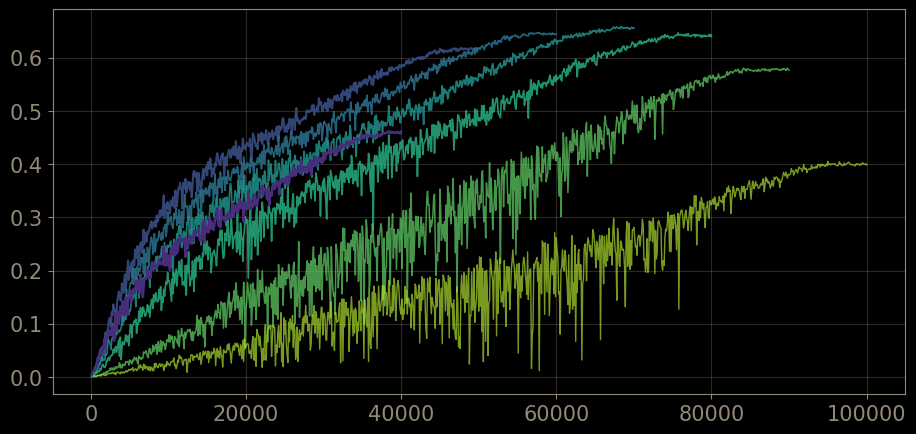

In [23]:
plt.clf()
fig= plt.figure(figsize=(11, 5), facecolor='k')
ax=fig.add_subplot(111, facecolor='k')
m='plain8'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.8, alpha=1.0, zorder=10)

m='plain14'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.5, alpha=0.85)

m='plain20'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain26'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain34'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

m='plain56'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.1, alpha=0.75)

m='plain74'
plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1., alpha=0.7)
style_ax(ax)

ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
# plt.savefig(str(save_dir/('p24df_'+str(count).zfill(4)+'.png')), dpi=350)

## P48, ResNet Boi

In [16]:
save_dir=Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/p48')
save_dir.mkdir(exist_ok=True)

  2%|▋                                        | 19/1099 [00:03<03:27,  5.21it/s]/tmp/ipykernel_1360882/1451362447.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig= plt.figure(figsize=(11, 5), facecolor='k')
100%|███████████████████████████████████████| 1099/1099 [03:36<00:00,  5.07it/s]


<Figure size 640x480 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

...

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

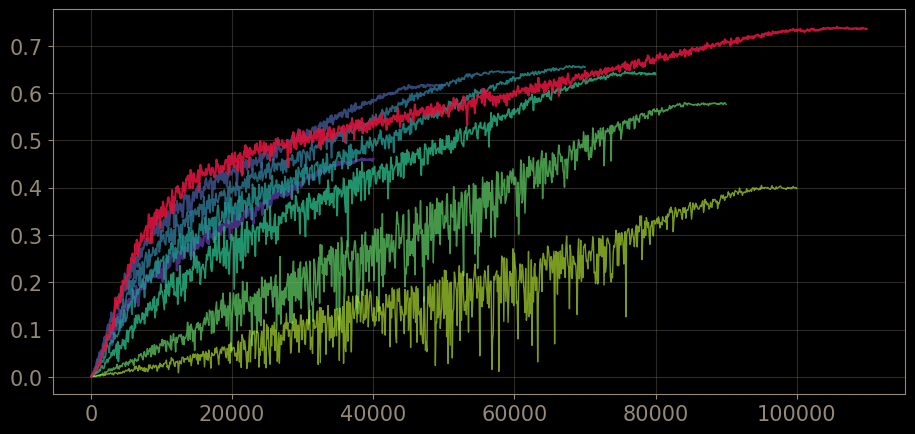

In [17]:
count=0
for i in tqdm(range(1, len(M['resnet74']["step"]))):    
    plt.clf()
    fig= plt.figure(figsize=(11, 5), facecolor='k')
    ax=fig.add_subplot(111, facecolor='k')
    m='plain8'
    plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.8, alpha=1.0)

    m='plain14'
    plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.5, alpha=0.85)

    m='plain20'
    plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

    m='plain26'
    plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

    m='plain34'
    plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.2, alpha=0.85)

    m='plain56'
    plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1.1, alpha=0.75)
    
    m='plain74'
    plt.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m, lw=1., alpha=0.7)

    m='resnet74'
    plt.plot(M[m]["step"][:i], M[m]["val_top1"][:i], color=color_of(m), label=m, lw=1.5, alpha=0.9)
    
    style_ax(ax)
    
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    plt.savefig(str(save_dir/('p48_'+str(count).zfill(4)+'.png')), dpi=350)
    count+=1

## Intro Bro

In [17]:
save_dir=Path('/home/stephen/Stephencwelch Dropbox/welch_labs/resnet/hackin/intro_curves')
save_dir.mkdir(exist_ok=True)

  2%|▊                                         | 19/999 [00:02<02:33,  6.38it/s]/tmp/ipykernel_4054281/3465322014.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig= plt.figure(figsize=(11, 5), facecolor='k')
100%|█████████████████████████████████████████| 999/999 [03:07<00:00,  5.32it/s]


<Figure size 640x480 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

...

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

<Figure size 1100x500 with 0 Axes>

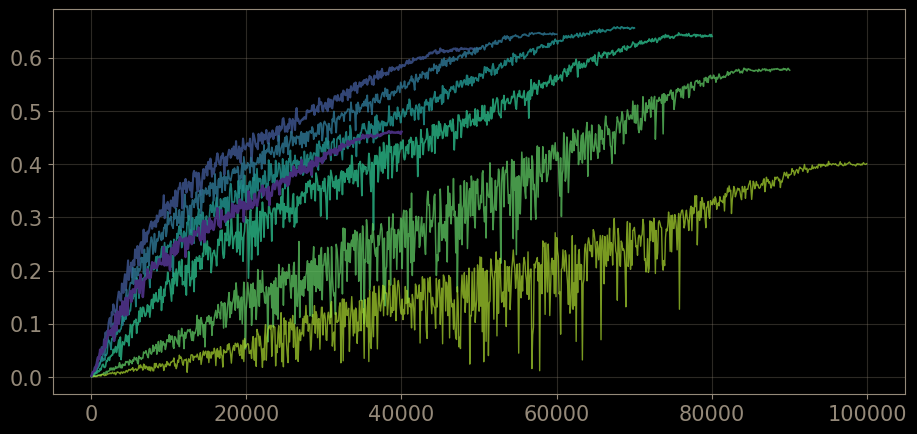

In [18]:
count=0
for i in tqdm(range(1, len(M['plain74']["step"]))):    
    plt.clf()
    fig= plt.figure(figsize=(11, 5), facecolor='k')
    ax=fig.add_subplot(111, facecolor='k')
    m='plain8'
    plt.plot(M[m]["step"][:i], M[m]["val_top1"][:i], color=color_of(m), label=m, lw=1.8, alpha=1.0, zorder=10)

    m='plain14'
    plt.plot(M[m]["step"][:i], M[m]["val_top1"][:i], color=color_of(m), label=m, lw=1.5, alpha=0.85)

    m='plain20'
    plt.plot(M[m]["step"][:i], M[m]["val_top1"][:i], color=color_of(m), label=m, lw=1.2, alpha=0.85)

    m='plain26'
    plt.plot(M[m]["step"][:i], M[m]["val_top1"][:i], color=color_of(m), label=m, lw=1.2, alpha=0.85)

    m='plain34'
    plt.plot(M[m]["step"][:i], M[m]["val_top1"][:i], color=color_of(m), label=m, lw=1.2, alpha=0.85)

    m='plain56'
    plt.plot(M[m]["step"][:i], M[m]["val_top1"][:i], color=color_of(m), label=m, lw=1.1, alpha=0.75)
    
    m='plain74'
    plt.plot(M[m]["step"][:i], M[m]["val_top1"][:i], color=color_of(m), label=m, lw=1., alpha=0.7)
    style_ax(ax)
    
    ax.grid(True, color=CHILL_BROWN, alpha=0.3, linewidth=0.8)
    plt.savefig(str(save_dir/('intro_1_'+str(count).zfill(4)+'.png')), dpi=350)
    count+=1

## Accuracy Plots

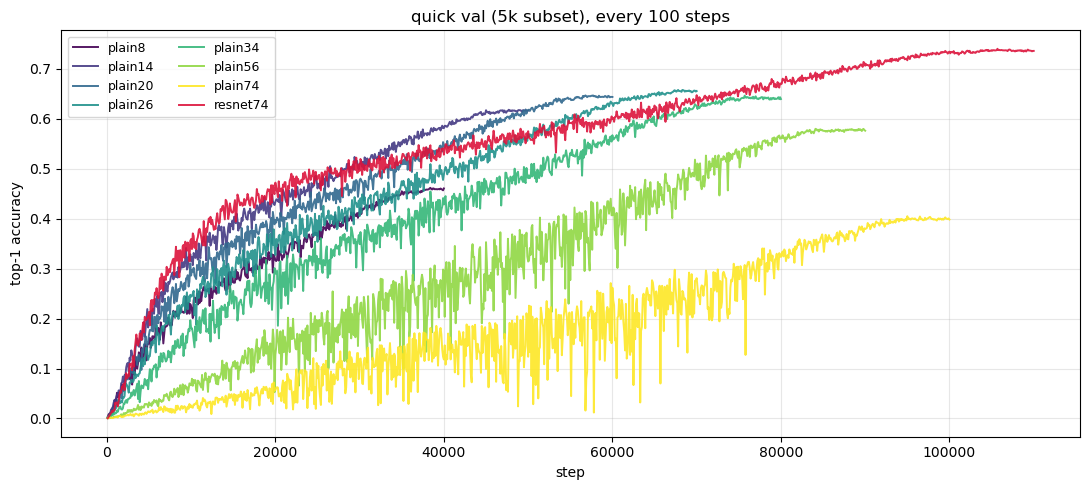

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
for m in MODELS:
    ax.plot(M[m]["step"], M[m]["val_top1"], color=color_of(m), label=m,
            lw=1.4, alpha=0.9)
ax.set(xlabel="step", ylabel="top-1 accuracy",
       title="quick val (5k subset), every 100 steps")
ax.legend(ncol=2, fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout()

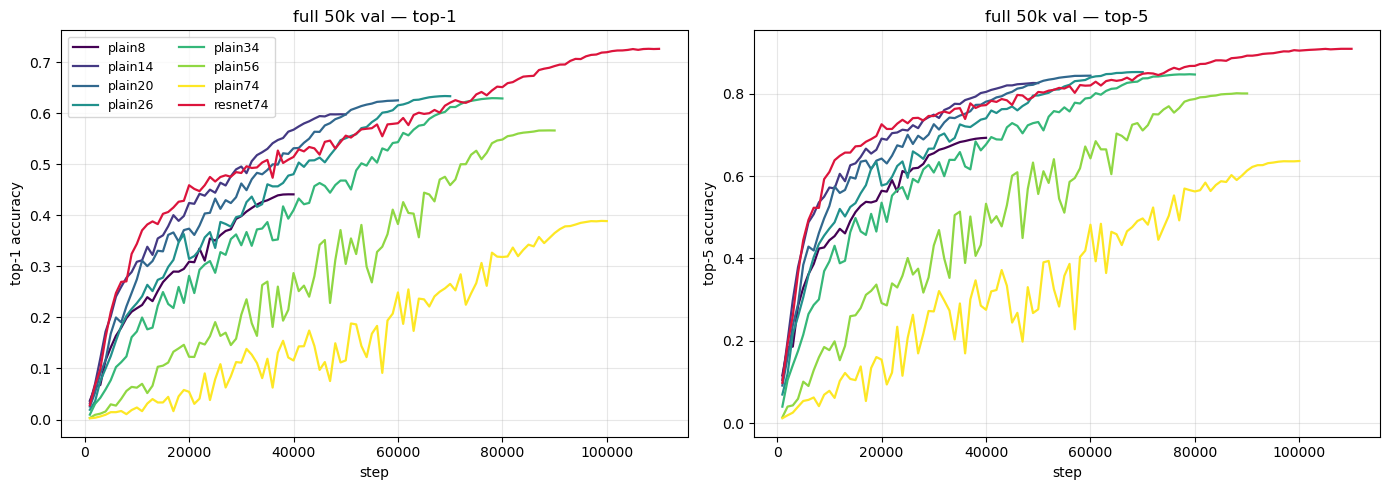

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for m in MODELS:
    steps = M[m]["step"]
    for ax, key, lbl in [(axes[0], "full_val_top1", "top-1"),
                          (axes[1], "full_val_top5", "top-5")]:
        v = M[m][key]
        keep = ~np.isnan(v)
        ax.plot(steps[keep], v[keep], color=color_of(m), label=m, lw=1.6)
for ax, lbl in zip(axes, ["top-1", "top-5"]):
    ax.set(xlabel="step", ylabel=f"{lbl} accuracy",
           title=f"full 50k val — {lbl}")
    ax.grid(alpha=0.3)
axes[0].legend(ncol=2, fontsize=9)
plt.tight_layout()

In [7]:
M['plain8'].keys()

dict_keys(['step', 'wall_time', 'train_loss', 'train_loss_avg', 'train_top1', 'lr', 'grad_norm', 'weight_norm', 'imgs_per_sec', 'val_top1', 'val_top5', 'val_err1', 'val_loss', 'block_grad_norms', 'block_act_mean', 'block_act_std', 'full_val_top1', 'full_val_top5', 'full_val_err1', 'full_val_loss'])

In [8]:
M['plain8']['full_val_top1'][-1]

np.float64(0.44088)

In [9]:
M['plain8']['step'][-1]

np.float64(40000.0)

In [10]:
model = load_model('plain8')

In [11]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): PlainBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
  )
  (layer2): Sequential(
    (0): PlainBasicBlock(
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, a

In [12]:
model = load_model('plain14')

In [13]:
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): PlainBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): PlainBasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_r

In [1]:
# for s,a in zip(M['plain14']['step'], M['plain14']['full_val_top1']):
#     print(s,a)

In [15]:
# 40000.0 0.56742
# 50000.0 0.59748

In [16]:
i=399

for m in ["plain8", "plain14", "plain20", "plain26", "plain34", "plain56", "plain74",  "resnet74"]:
    print(m, M[m]['step'][i], M[m]['full_val_top1'][i])

plain8 40000.0 0.44088
plain14 40000.0 0.56742
plain20 40000.0 0.53114
plain26 40000.0 0.4803
plain34 40000.0 0.4099
plain56 40000.0 0.28684
plain74 40000.0 0.11568
resnet74 40000.0 0.51412


In [17]:
i=399

for m in ['plain8', "plain14", "plain20", "plain26", "plain34", "plain56", "plain74",  "resnet74"]:
    print(m, M[m]['step'][-1], M[m]['full_val_top1'][-1])

plain8 40000.0 0.44088
plain14 50000.0 0.59748
plain20 60000.0 0.6249
plain26 70000.0 0.63304
plain34 80000.0 0.62862
plain56 90000.0 0.56592
plain74 100000.0 0.38856
resnet74 110000.0 0.72574


In [18]:
i=-1
M['plain20']['step'][i], M['plain20']['full_val_top1'][i]

(np.float64(60000.0), np.float64(0.6249))